# Assignment 2: Scalability of Support Vector Machines
## Miles Nordwall, Nathan Nail

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.svm import LinearSVC as skSVC
from datetime import datetime

In [3]:
NUM_ITER = 100
SEED = 96
ETA = 0.001
EPOCHS = 50

## Task #1 Implement LinearSVC

In [5]:
class LinearSVC(object):
    """
    Linear Support Vector Classifier with SGD
    Params: 
    eta (float) : Learning rate (between 0.0 and 1.0)
    n_iter (int) : Number of passes over the training dataset.
    random_state (int) : Random number generator seed for random weight initialization.

    Attrs:
    w_ (1d-array) : Weights after fitting with bias absorbed at X[0].
    losses_ (list) : Hinge Loss with L2-regularization loss function values in each epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.rand_gen = []
        self.w_initialized = False

    def fit(self, X, y, C=0.1):
        """
        Learns parameters from the training data
        Uses SGD
        Params:
        X {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
        y (array-like) ,shape = [n_examples]
        Target values.
        C {float} = regularization hyperparameter 

        Returns:
        self : Instance of LinearSVC
        """
        self.losses_ = []
        X = self._initialize_weights(X,X.shape[1])
        c_n = C /X.shape[0]
        
        for _ in range(self.n_iter):
            #shuffle for SGD
            X, y = self._shuffle(X, y)
            epoch_losses = []
            
            for xi, yi in zip(X, y):
                
                y_hat = self.net_input(xi)
                fn_margin = 1 - (yi*y_hat)
                Li = np.maximum(0,fn_margin)

                b_update = 0
                if fn_margin > 0: #case 1
                    gd = self.w_ + c_n * (-yi*xi) #dL/dw
                    b_update = -yi
                else: #case 2
                    gd = self.w_
                epoch_losses.append(Li)

                #update weights and bias
                self.w_ += self.eta* (-gd)
                self.b_ += self.eta* b_update
            avg_loss = np.mean(epoch_losses)
            self.losses_.append(avg_loss)
        return self
        

    
    def _initialize_weights(self, X, m):
        """Initialize weights to small random numbers
        """
        self.b_ = np.float_(0.)
        self.rand_gen = np.random.RandomState(self.random_state)
        self.w_ = self.rand_gen.normal(loc=0.0, scale=0.01,
                                  size=m)
        self.w_initialized = True
        return X
        

    def _update_weights(self, xi, y):
        """Calculate hinge loss then apply GD to L wrt w_"""
        y_hat = self.net_input(xi)
        
        Li = np.max(0, 1 - (y*y_hat))
        loss = c_n * (Li + (0.5 * (self.w_.shape[0])^2))
        self.w_ += self.w_ + self.eta - loss
        self.b_ += gd
        return loss
        
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rand_gen.permutation(len(y))
        return X[r], y[r]

    def net_input(self, X): 
        """Calculate net input"""
        return np.dot(X, self.w_) - self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.sign(self.net_input(X))
    
        

To implement a Linear SVC in Python, we can start with a basic perceptron template and modify it to suit the needs of the model. The main major changes needed were to the loss calculation and the model update. This implementation of the SVC uses hinge loss with L2 regularization. 

- For the loss update, we use the following equation: 

$$ L_i = \max(0, 1 - (y_i * \hat{y}_i)) $$

- To update the model, we take the gradient of this loss:

$$ w = w + \eta \frac{\partial L}{\partial w} $$
$$ b = b + \eta \frac{\partial L}{\partial b} $$

To compute the total loss, we loop over pairs of observations `for x_i, target in zip(X, y)` similar to the perceptron. In this loop, we perform two calculations. One operation calculates the standard hinge loss, which we can use to evaluate how quickly the model converges with each epoch. Another operation computes the gradient of the hinge loss, which will be used in a later calculation to determine how to update the model. 

## Task #2 make_classification function
$$\bar{a}^T \bar{x} = b$$
$$\{ \bar{x} \in \mathbb{R}^d | \bar{a}^T \bar{x} = b\}$$
$$\text{where } b=0$$

In [8]:
from sklearn.model_selection import train_test_split
def make_classification(d,n, u=100,seed=SEED):
    """
    Generates a set of linearly seperable data
    based on a random seperation hyperplane
    d (int) : dimension of set of points
    """
    rand_gen = np.random.RandomState(seed)
    #generate random vector a s.t ||a||=d
    a = rand_gen.random(size=d) #TODO values are between [0-1] btw, is that okay?
    
    #randomly select n samples in range of [-u,u] in each dimension using a gaussian
    X = rand_gen.normal(scale=u,size=(n,d))    
    
    #give each xi a label yi 
    y = []
    for j in range(n):
        if a.T.dot(X[j]) < 0: #is this correct?
            yi = -1
        else:
            yi = 1
        y.append(yi)
    Y = np.array(y)

    #splits the data into train and test datas
    split_idx = int(np.ceil(n * 0.7))
    X_train, X_test = np.split(X, [split_idx])
    Y_train, Y_test = np.split(Y, [split_idx])

    
    return X_train, X_test, Y_train, Y_test

In [9]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None,
                          resolution=0.02):
    """taken from textbook"""
    
    # setup marker generator and color map
    markers = ('o', 'x', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    facecolor='black')
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Test set')

### Task 2: Demo
Task 2 has us implement a generator that produces linearly seperable sets of data using knowledge from linear algebra. To demonstrate the efficacy of the code, we can set the number of dimensions to 2 with 100 data points.

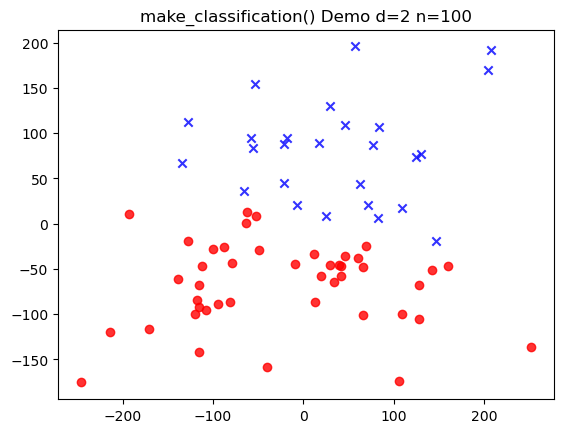

In [11]:
X_train, X_test, Y_train, Y_test = make_classification(d=2,n=100,u=100,seed=SEED)
markers = ('o', 'x', '^', 'v', '<')
colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
plt.title("make_classification() Demo d=2 n=100")
for idx, cl in enumerate(np.unique(Y_train)):
        plt.scatter(x=X_train[Y_train == cl, 0],
                    y=X_train[Y_train == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    facecolor='black')

With seed 96 on this specific RNG, we can see a clear split between two clouds of data. This data would make for a easy set on which to train a model.

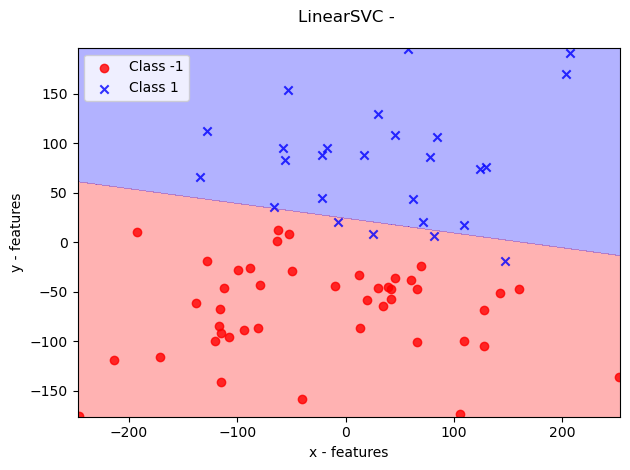

In [13]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=100, eta=ETA)
X_train, X_test, Y_train, Y_test = make_classification(d=2,n=100,u=100,seed=SEED)

svc_start = datetime.now()
svc.fit(X_train, Y_train)
svc_end = datetime.now()
SVC_t = (svc_end - svc_start).total_seconds() *1000

plot_decision_regions(X_train, Y_train, classifier=svc)
plt.title(f'LinearSVC - \n')
plt.xlabel('x - features')
plt.ylabel('y - features')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Task 3: Comparing Time and Loss Convergence for Customer LinearSVC

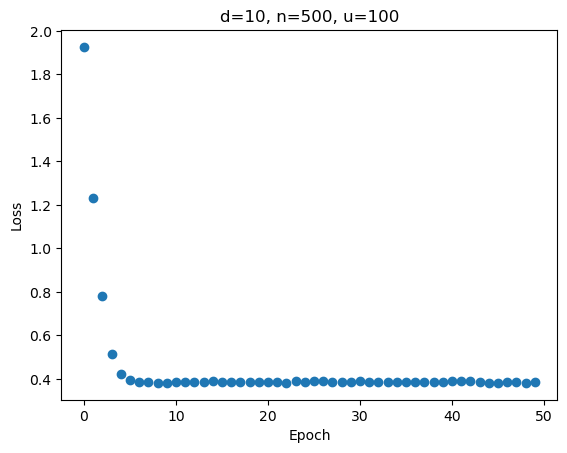

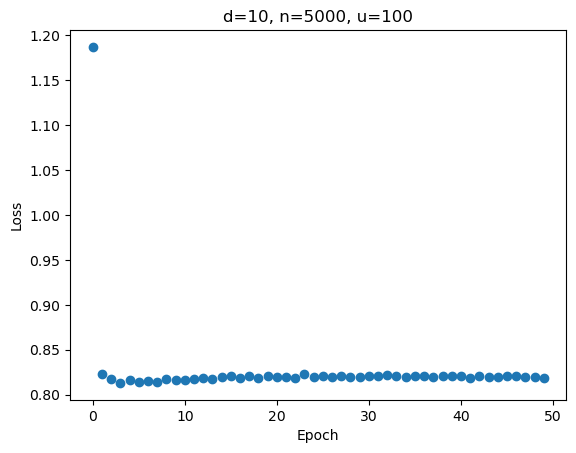

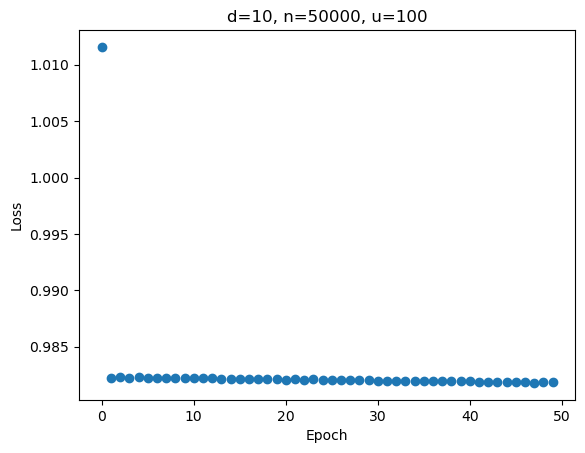

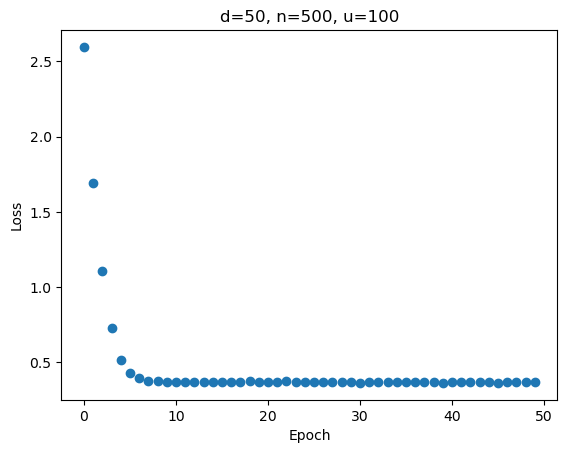

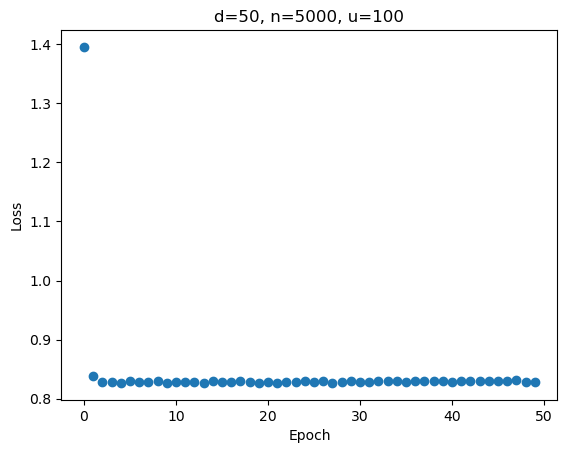

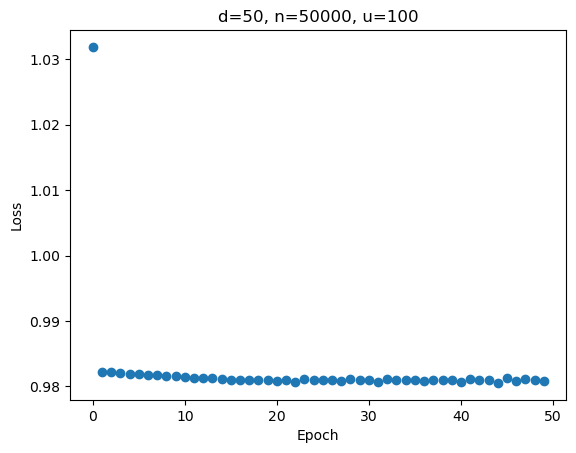

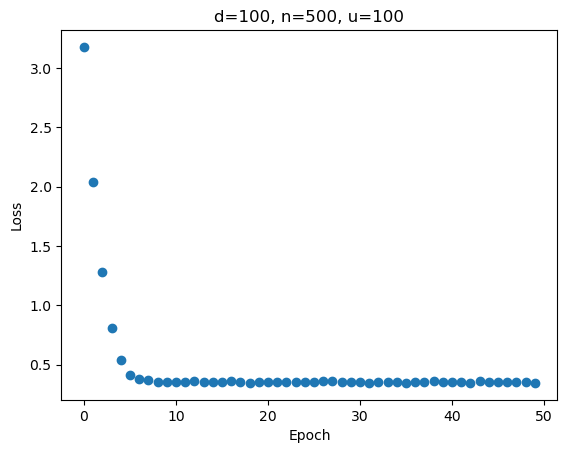

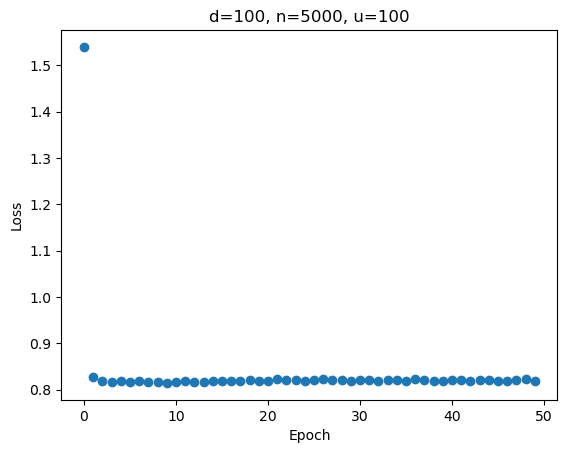

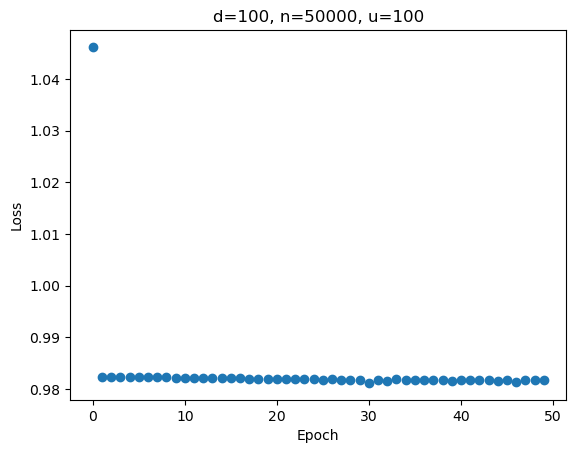

   Epochs  Dim  Samples       Time  Loss Convergence
0      50   10      500   0.107581          1.538735
1      50   10     5000   1.158536          0.368321
2      50   10    50000  11.745709          0.029704
3      50   50      500   0.101873          2.228722
4      50   50     5000   1.167460          0.566432
5      50   50    50000  11.898754          0.051047
6      50  100      500   0.099339          2.830079
7      50  100     5000   1.192484          0.721349
8      50  100    50000  12.099435          0.064410


In [15]:
import itertools

n_dims = [10, 50, 100]
n_samples = [500, 5000, 50000]

sets = []
errors = []

headers = ["Epochs","Dim","Samples","Time","Loss Convergence"]
d_s = []
svc1 = LinearSVC(n_iter=50, eta=ETA)


def plot_losses(loss_values, dims, samples):
    x_vals = np.linspace(0, len(loss_values)-1, len(loss_values))
    plt.scatter(x_vals, loss_values)
    plt.title(f"d={dims}, n={samples}, u=100")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

for dims, samples in itertools.product(n_dims, n_samples):
    X_train, X_test, Y_train, Y_test = make_classification(d=dims,n=samples,u=100,seed=SEED)
    
    fit_start = time.clock_gettime(5)
    svc1.fit(X_train, Y_train, C=0.1)
    fit_end = time.clock_gettime(5)
    
    
    end_weight = svc1.w_
    errors.append(( svc1.losses_, dims, samples))

    d_s.append([EPOCHS, dims, samples, fit_end - fit_start, svc1.losses_[0] - svc1.losses_[-1]])  #drop in loss from first to last sample
    

for l,d,s in errors:
    plot_losses(l,d,s)

np.set_printoptions(suppress=True, precision=4)
table = pd.DataFrame(d_s, columns=headers)
print(table)


### Task 3: Explanation
To implement task 3, we created 9 unique datasets covering all 9 permutations of the number of dimensions and number of samples. With this, we can test the performance impact of using varying numbers of each and observe any differences in the convergence pattern and time taken to run.

For this problem, we use a learning rate η of 0.001 and 50 iterations. C is set to 0.1.

### Loss Plots
The plots start at 10 dimensions and 500 samples, increasing by sample size until reaching the next dimension. Error rate is plotted on the y-axis against the epoch number on the x-axis. 

A couple of patterns can be extrapolated from these plots. For one, it takes models with more features a longer period of time to converge. The slope of the convergence curve, particularly for $n = 50,000$, is either just as steep (in the $d = 100$ case) or notably steeper (in the $d = 10$ case). This indicates that more epochs are required in order to accomodate and properly fit the rest of the data. 

Another pattern that can be witnessed is the smoothness of each convergence curve. When the ratio of dimensions to samples, $\frac{n}{d}$ is low, we can see a more jittery convergence pattern. This is most evidence in the case where $d = 100$ and $n = 500$. Given that the hinge loss is either 0 or 2 for each feature along with the greater complexity of a model with many features, there is a greater likelihood that an observation does not get properly classified and can shoot up the error rate on specific epochs. 

Regardless, it seems that performance of the model, when measured by the ability to converge, holds up well when dimensions and sample numbers get large. 

### Runtimes

The increase in the number of samples was a much higher driver of increased runtime than increasing the dimensionality. Increasing by a factor of 10 between 500, 5000, and 50000 resulted in a proportional increase in runtime by roughly an order of magnitude. This indicates pseudo-$O(n)$ levels of performance, likely $O(kn)$ for some constant k. The outer loop of `n_iter` is a smaller and smaller proportion of the runtime as $n$ gets larger. In contrast, the inner loop calculating each sample is strictly $O(n)$ as it must iterate over each sample-label pair. 

While converging performance holds up well, the runtime of this implementation may not scale the best compared to others, specifically those in `sklearn` that tend to always complete in under 1 second. Use of this implementation could cause issues with even larger datasets. 

### Task 4: sklearn LinearSVC Dual v Primal

Dual Table:
   Converged At  Dim  Samples      Time  Accuracy
0          2040   10      500  0.003270  1.000000
1          3455   10     5000  0.024817  0.999429
2          4012   10    50000  0.163702  0.999486
3         10422   50      500  0.076582  1.000000
4          9420   50     5000  0.216599  0.999143
5         14238   50    50000  1.473763  0.999229
6          3795  100      500  0.116943  1.000000
7         22580  100     5000  0.936710  0.999714
8         21382  100    50000  4.186280  0.999514
Primal Table:
   Converged At  Dim  Samples      Time  Accuracy
0            10   10      500  0.001412  1.000000
1            11   10     5000  0.002269  0.999429
2            13   10    50000  0.020069  0.999486
3            85   50      500  0.004197  1.000000
4            12   50     5000  0.012403  0.999143
5            14   50    50000  0.099868  0.999229
6           129  100      500  0.026439  1.000000
7            14  100     5000  0.022295  0.999714
8            14  100    

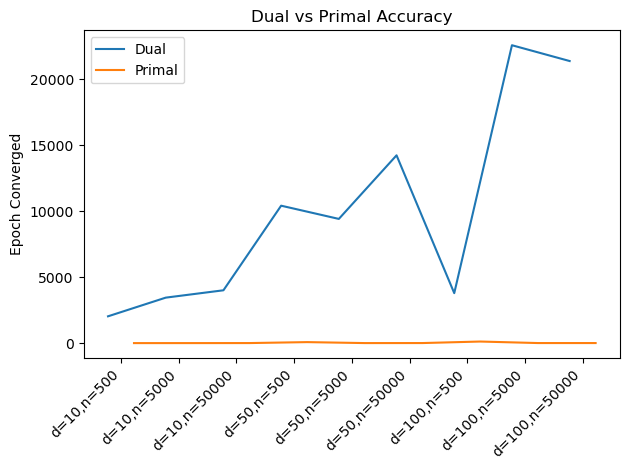

In [18]:
import itertools

n_dims = [10, 50, 100]
n_samples = [500, 5000, 50000]


headers = ["Converged At","Dim","Samples","Time","Accuracy"]
#rows for table that will display results from dual and primal models
d_s_d = []
d_s_p = []

#arryas of the corresponding epoch the model converged
conv_d = []
conv_p = []


for dims, samples in itertools.product(n_dims, n_samples):
    X_train, X_test, Y_train, Y_test = make_classification(d=dims,n=samples,u=100,seed=SEED)

    #time and fit dual svc
    fit_start = time.clock_gettime(5)
    dual = skSVC(loss = "squared_hinge", dual = True, max_iter=50000, C=0.001)
    dual.fit(X = X_train, y = Y_train)
    fit_end = time.clock_gettime(5)

    #time and fit primal svc
    fit_start_p = time.clock_gettime(5)
    primal = skSVC(loss = "squared_hinge", dual = False, max_iter=50000, C=0.001)
    primal.fit(X = X_train, y = Y_train)
    fit_end_p = time.clock_gettime(5)

    #predict and get accuracy 
    result_d = dual.predict(X_train)
    accuracy_d = dual.score(X_train, Y_train)
    
    result_p = primal.predict(X_train)
    accuracy_p = primal.score(X_train, Y_train)
    
    #keep track of epoch converged at 
    conv_d.append(dual.n_iter_)
    conv_p.append(primal.n_iter_)

    
    d_s_d.append([dual.n_iter_, dims, samples, fit_end - fit_start, accuracy_d])  
    d_s_p.append([primal.n_iter_, dims, samples, fit_end_p - fit_start_p, accuracy_p])  

#print table data
np.set_printoptions(suppress=True, precision=4)
table_d = pd.DataFrame(d_s_d, columns=headers)
table_p = pd.DataFrame(d_s_p, columns=headers)
print("Dual Table:")
print(table_d)
print("Primal Table:")
print(table_p)

#show Converged Epoch v Model Params plot
x = range(len(conv_d))
labels = [f"d={d},n={n}" for d,n in itertools.product(n_dims, n_samples)]
fig,axes = plt.subplots()
axes.plot([i - (0.45)/2 for i in x], conv_d, label='Dual')
axes.plot([i + (0.45)/2 for i in x], conv_p, label='Primal')
axes.set_xticks(list(x))
axes.set_xticklabels(labels, rotation=45, ha='right')
axes.set_ylabel('Epoch Converged')
axes.set_title('Dual vs Primal Accuracy')
axes.legend()
plt.tight_layout()
plt.show()



### Task 4 Explanation

We can now compare our model to those provided by `scikit-learn` to see how performance and convergence compare. We can compare plots used for task 3 against new data for this task. 

After experimenting a bit, we found the covergence was not always inevitable, the parameters and number of max_iter make a big difference. We found that the a C value of 0.001 gave us the best results. A small value of C ensures the model will not fit the data super close and the margin will be larger. When we tried larger values of C maybe of the tests did not converge.

From the line plot, we can see that both the primal model and custom SVC implementation consistently converge very quickly, tending to require only the first few epochs. This is vastly different than the dual model, which takes significantly more epochs and in a more jagged pattern. When running the dual model, it also takes substantially more time (from the perception of a human through measurement in seconds) than the other two by orders of magnitude. There is something specific about the dual model in the way it solves the optimization problem that creates more discontinuity; this could be attributed to the added complexity that the Lagrange multipliers can have on the model update. 

Given that the primal model can converge quickly and with relatively low time, it seems to be a good candidate for scalability. It manages to achieve the same results as the other two models and, in some cases, at a fraction of the time. 